**Part 2, Mini Project, Source code**

Student id: 25030999

What are the insights of professional golf performance in tournaments? 

Imported libraries that are reqired to build graphs and do analysis of the data.

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [46]:
dataset = pd.read_csv('liv_scores_2022_2024.csv')
dataset.head(5)

,Season,Venue,Date,Place,Name,Round1,Round2,Round3,Total,ToPar
0,2022,London,2022-06-09,1,Charl Schwartzel,65,66.0,72.0,203.0,-7.0
1,2022,London,2022-06-09,2,Hennie du Plessis,66,68.0,70.0,204.0,-6.0
2,2022,London,2022-06-09,T3,Branden Grace,68,72.0,65.0,205.0,-5.0
3,2022,London,2022-06-09,T3,Peter Uihlein,70,66.0,69.0,205.0,-5.0
4,2022,London,2022-06-09,5,Sam Horsfield,69,70.0,68.0,207.0,-3.0


Rows with missing scores and dublicates were removed to ensure fair comparison across years

In [47]:
dataset = dataset.dropna()

In [48]:
dataset.drop_duplicates(subset=None, keep='first')

,Season,Venue,Date,Place,Name,Round1,Round2,Round3,Total,ToPar
0,2022,London,2022-06-09,1,Charl Schwartzel,65,66.0,72.0,203.0,-7.0
1,2022,London,2022-06-09,2,Hennie du Plessis,66,68.0,70.0,204.0,-6.0
2,2022,London,2022-06-09,T3,Branden Grace,68,72.0,65.0,205.0,-5.0
3,2022,London,2022-06-09,T3,Peter Uihlein,70,66.0,69.0,205.0,-5.0
4,2022,London,2022-06-09,5,Sam Horsfield,69,70.0,68.0,207.0,-3.0
...,...,...,...,...,...,...,...,...,...,...
1650,2024,Chicago,2024-09-13,T47,Matthew Wolff,76,72.0,67.0,215.0,5.0
1651,2024,Chicago,2024-09-13,51,Jason Kokrak,73,73.0,70.0,216.0,6.0
1652,2024,Chicago,2024-09-13,52,Cameron Smith,73,73.0,74.0,220.0,10.0
1653,2024,Chicago,2024-09-13,53,Hudson Swafford,78,78.0,67.0,223.0,13.0


First, I need to extract the venues and the years that were played on the tournament in order to search for the specific courses that were played.

In [28]:
dataset.groupby('Venue')['Season'].unique()

Venue
Adelaide            [2023, 2024]
Andalucia           [2023, 2024]
Bangkok                   [2022]
Bedminster          [2022, 2023]
Boston                    [2022]
Chicago       [2022, 2023, 2024]
DC                        [2023]
Greenbrier          [2023, 2024]
Hong Kong                 [2024]
Houston                   [2024]
Jeddah        [2022, 2023, 2024]
Las Vegas                 [2024]
London              [2022, 2023]
Mayakoba            [2023, 2024]
Miami                     [2024]
Nashville                 [2024]
Orlando                   [2023]
Portland                  [2022]
Singapore           [2023, 2024]
Tucson                    [2023]
Tulsa                     [2023]
UK                        [2024]
Name: Season, dtype: object

After some reaserch, I have found the specific courses that were played for each venue, and was able to get the type of the course and its yardage. Next, I will add this information in new columns through mapping.

In [49]:
# Create mapping dictionary with the information about course name, 
# coure type and yardage based on the venue
course_mapping = {
    'Andalucia': {
        'course_name': 'Real Club Valderrama',
        'course_type': 'Parkland',
        'yardage': 7000
    },
    'Adelaide':{
        'course_name': 'The Grange Golf Club',
        'course_type': 'Parkland',
        'yardage': 6850
    },
    'Bangkok':{
        'course_name': 'Stonehill Golf Club',
        'course_type': 'Parkland',
        'yardage': 7200
    },
    'Bedminster':{
        'course_name': 'Trump National Golf Club Bedminster',
        'course_type': 'Parkland',
        'yardage': 7300
    },
    'Boston':{
        'course_name': 'The Oaks Golf Course at The International',
        'course_type': 'Parkland',
        'yardage': 7120
    },
    'Chicago':{
        'course_name': 'Bolingbrook Golf Club',
        'course_type': 'Parkland',
        'yardage': 7141
    },
    'DC':{
        'course_name': 'Trump National Golf Club Washington',
        'course_type': 'Parkland',
        'yardage': 7479
    },
    'DC':{
        'course_name': 'Trump National Golf Club Washington',
        'course_type': 'Parkland',
        'yardage': 7479
    },
    'Greenbrier':{
        'course_name': 'The Old White Course (The Greenbrier)',
        'course_type': 'Parkland',
        'yardage': 7300
    },
    'Hong Kong':{
        'course_name': 'Hong Kong Golf Club',
        'course_type': 'Parkland',
        'yardage': 6900
    },
    'Houston':{
        'course_name': 'Golf Club Huston',
        'course_type': 'Parkland',
        'yardage': 7425
    },
    'Jeddah':{
        'course_name': 'Royal Greens Golf & Country Club',
        'course_type': 'Desert',
        'yardage': 7400
    },
    'Las Vegas':{
        'course_name': 'Las Vegas Country Club',
        'course_type': 'Desert',
        'yardage': 7200
    },
    'London':{
        'course_name': 'Centurion Club',
        'course_type': 'Parkland',
        'yardage': 7200
    },
    'Mayakoba':{
        'course_name': 'El Camaleón Golf Club',
        'course_type': 'Resort',
        'yardage': 7300
    },
    'Miami':{
        'course_name': 'Trump National Doral Golf Club',
        'course_type': 'Resort',
        'yardage': 7528
    },
    'Nashville':{
        'course_name': 'The Groove',
        'course_type': 'Parkland',
        'yardage': 7300
    },
    'Orlando':{
        'course_name': 'Orange County National Golf Center',
        'course_type': 'Parkland',
        'yardage': 7200
    },
    'Portland':{
        'course_name': 'Pumpkin Ridge Golf Club',
        'course_type': 'Parkland',
        'yardage': 7300
    },
    'Singapore':{
        'course_name': 'Sentosa Golf Club (Serapong Course)',
        'course_type': 'Resort',
        'yardage': 7000
    },
    'Tucson':{
        'course_name': 'The Gallery Golf Club',
        'course_type': 'Desert',
        'yardage': 7100
    },
    'Tulsa':{
        'course_name': 'Cedar Ridge Country Club',
        'course_type': 'Parkland',
        'yardage': 7300
    },
    'UK':{
        'course_name': 'JCB Golf & Country Club',
        'course_type': 'Parkland',
        'yardage': 7276
    }
}

# Add new columns based on venue mapping, ChatLog1
dataset['course_name'] = dataset['Venue'].map(lambda x: course_mapping.get(x, {}).get('course_name'))
dataset['course_type'] = dataset['Venue'].map(lambda x: course_mapping.get(x, {}).get('course_type'))
dataset['yardage'] = dataset['Venue'].map(lambda x: course_mapping.get(x, {}).get('yardage'))
dataset[['Venue', 'course_name', 'course_type', 'yardage']]

,Venue,course_name,course_type,yardage
0,London,Centurion Club,Parkland,7200
1,London,Centurion Club,Parkland,7200
2,London,Centurion Club,Parkland,7200
3,London,Centurion Club,Parkland,7200
4,London,Centurion Club,Parkland,7200
...,...,...,...,...
1650,Chicago,Bolingbrook Golf Club,Parkland,7141
1651,Chicago,Bolingbrook Golf Club,Parkland,7141
1652,Chicago,Bolingbrook Golf Club,Parkland,7141
1653,Chicago,Bolingbrook Golf Club,Parkland,7141


Now I need to see what are the types of the courses that are in the dataset and what is the range of the vlaues for yardage.

In [30]:
# Get unique course types
dataset['course_type'].unique()

array(['Parkland', 'Desert', 'Resort'], dtype=object)

In [50]:
# Get the range of yardage values
print(f"Minimum yardage: {dataset['yardage'].min()}")
print(f"Maximum yardage: {dataset['yardage'].max()}")

Minimum yardage: 6850
Maximum yardage: 7528


Now I want to plot the relationship between the type of course and the avarage yardages of it.

In [51]:
# Creating a colormap to use apppropriate colors across different graphs
color_map = {
    'Parkland': '#F3FD9B',
    'Desert': '#A4FAF4',
    'Resort': '#FF9DC4'
}

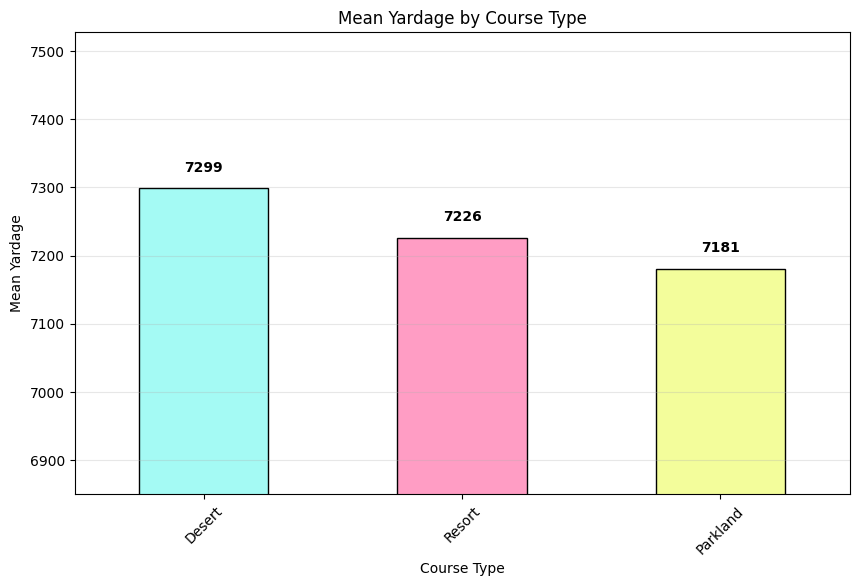

In [52]:
# Calculate mean yardage by course type
mean_yardage = dataset.groupby('course_type')['yardage'].mean().sort_values(ascending=False)

# Create bar plot
plt.figure(figsize=(10, 6))
colors = [color_map[course_type] for course_type in mean_yardage.index]
bars = mean_yardage.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Mean Yardage by Course Type')
plt.xlabel('Course Type')
plt.ylabel('Mean Yardage')
plt.ylim(6850, 7528)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Add notation of values on top of bars, ChatLog2
for i, v in enumerate(mean_yardage):
    plt.text(i, v + 20, f'{v:.0f}', ha='center', va='bottom', fontweight='bold')

plt.show()


Now I want to explore the relatonship between performance and the type of the course.

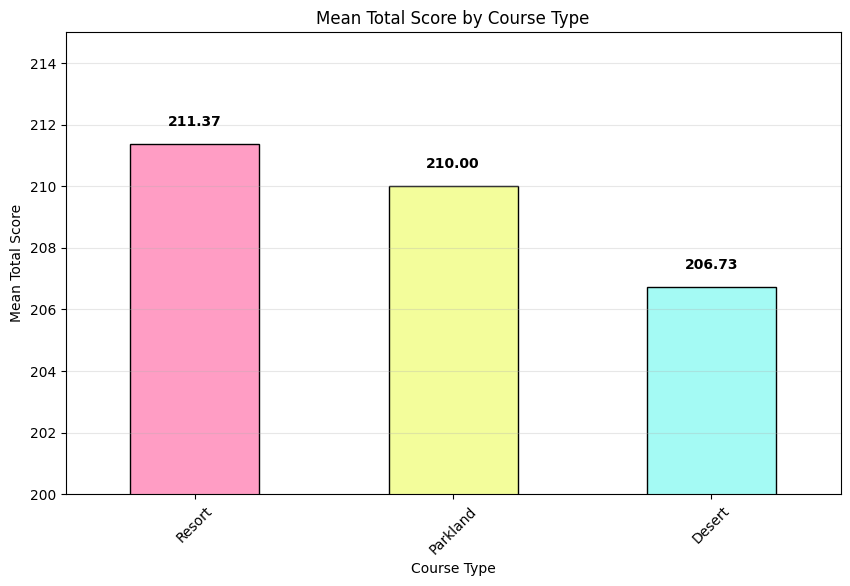

In [53]:
# Calculate mean total score by course type
mean_total = dataset.groupby('course_type')['Total'].mean().sort_values(ascending=False)

# Create bar plot
plt.figure(figsize=(10, 6))
colors = [color_map[course_type] for course_type in mean_total.index]
bars = mean_total.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Mean Total Score by Course Type')
plt.xlabel('Course Type')
plt.ylabel('Mean Total Score')
plt.ylim(200,215)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Add values on top of bars
for i, v in enumerate(mean_total):
    plt.text(i, v + 0.5, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')
plt.show()

Now I want to explore the relationship between the yardage and the total scores to see if there is one

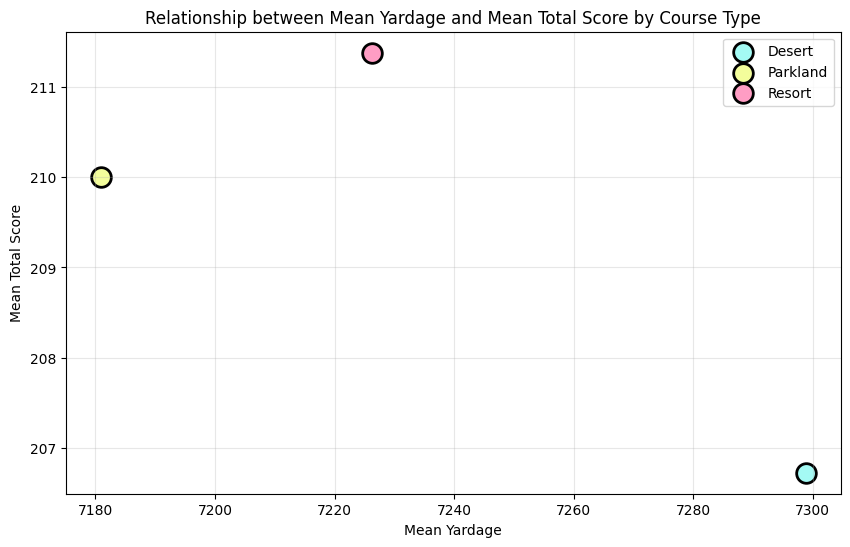

In [54]:
# Calculate mean yardage and mean total score by course type
# Create a dataframe with mean yardage, mean total and the course type
course_stats = dataset.groupby('course_type').agg({
    'yardage': 'mean',
    'Total': 'mean'
}).reset_index()

# Create scatter plot
plt.figure(figsize=(10, 6))
# Iterate through the course type and get the mean yeardage
# and total to generate a scatter point 
for course_type in course_stats['course_type']:
    data = course_stats[course_stats['course_type'] == course_type]
    plt.scatter(data['yardage'], data['Total'], 
                color=color_map[course_type], 
                s=200, 
                edgecolor='black', 
                linewidth=2,
                label=course_type)

plt.xlabel('Mean Yardage')
plt.ylabel('Mean Total Score')
plt.title('Relationship between Mean Yardage and Mean Total Score by Course Type')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


After looking at the graph, we can conclude that the yardage of the course does not affect the performance of the players (looking at the mean values), therefore, we can look closely at wether the yardage creates any sort of pattern in the sequential rounds. For that, I will create a bar chart with the mean of each round and the course type.

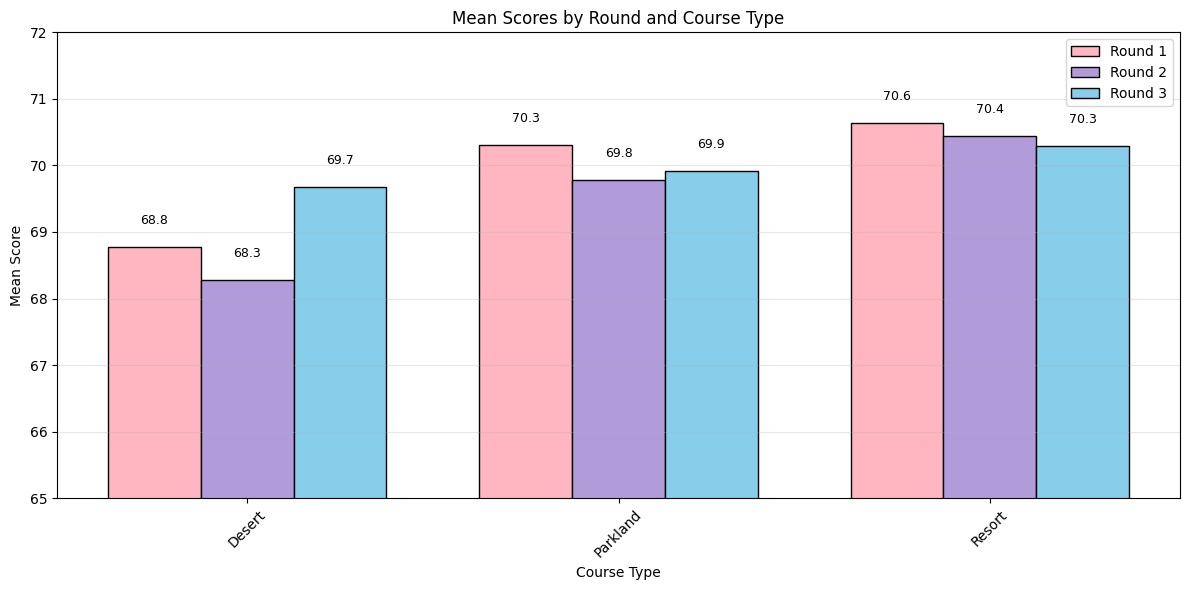

In [55]:
# Calculate mean scores for each round by course type
round_means = dataset.groupby('course_type')[['Round1', 'Round2', 'Round3']].mean()

fig, ax = plt.subplots(figsize=(12, 6))

# Set the width of bars and positions, ChatLog3
x = np.arange(len(round_means.index))
width = 0.25

# Create unique bars for each round
# Marked the next 3 lines
bars1 = ax.bar(x - width, round_means['Round1'], width, label='Round 1', color='#FFB6C1', edgecolor='black')
bars2 = ax.bar(x, round_means['Round2'], width, label='Round 2', color='#B19CD9', edgecolor='black')
bars3 = ax.bar(x + width, round_means['Round3'], width, label='Round 3', color='#87CEEB', edgecolor='black')

# Add labels and title
ax.set_xlabel('Course Type')
ax.set_ylabel('Mean Score')
ax.set_ylim(65,72)
ax.set_title('Mean Scores by Round and Course Type')
ax.set_xticks(x)
ax.set_xticklabels(round_means.index, rotation=45)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Iterate through rounds and then specific course
# types at each round and get the values, plot them
# Marked the next 5 lines
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.3,
                f'{height:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


Now I want to explore into players patterns, and for that I want to look at the mean total scores of all the players.

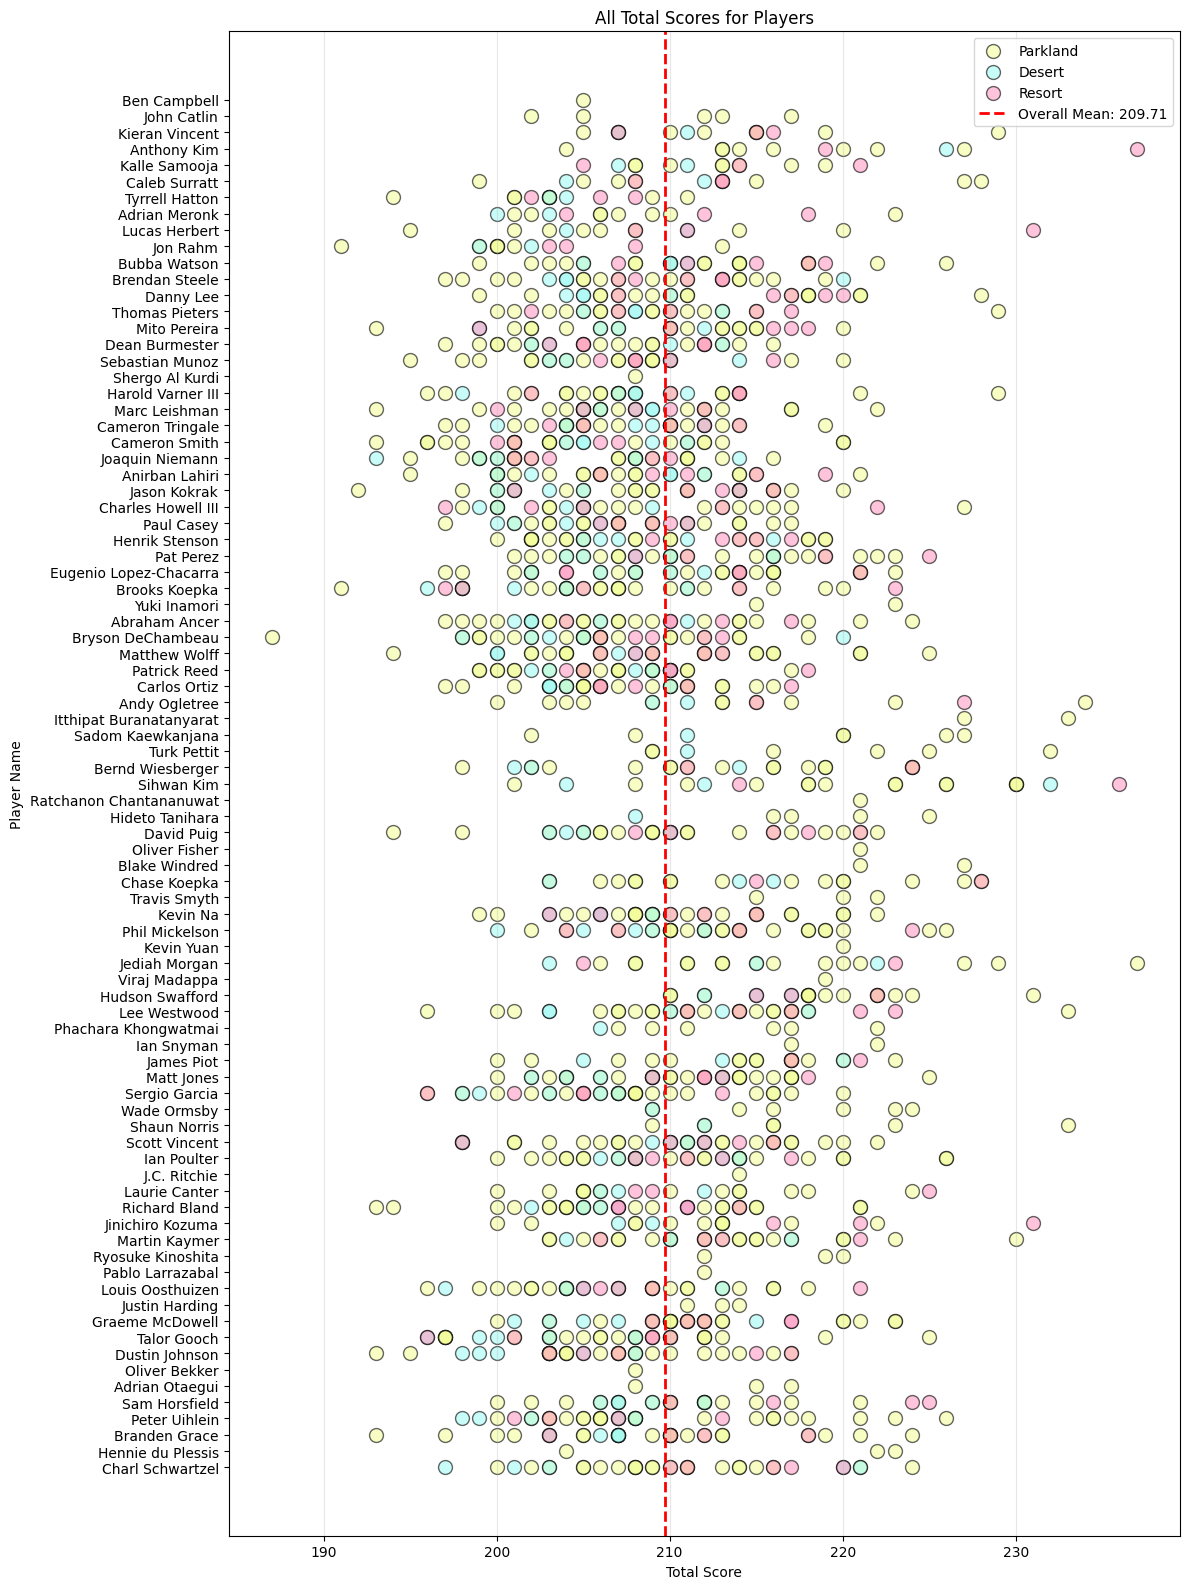

In [56]:

overall_mean_all_players = dataset['Total'].mean()

# Create scatter plot with all individual scores colored by course type
plt.figure(figsize=(12, 16))

# Plot each course type separately to get the colors, ChatLog4
for course_type in dataset['course_type'].unique():
    course_data = dataset[dataset['course_type'] == course_type]
    plt.scatter(course_data['Total'], course_data['Name'], 
                s=100, alpha=0.6, edgecolor='black', linewidth=1, 
                color=color_map[course_type], label=course_type)

# Add vertical line for overall mean score
plt.axvline(x=overall_mean_all_players, color='red', linestyle='--', linewidth=2, 
            label=f'Overall Mean: {overall_mean_all_players:.2f}')

plt.xlabel('Total Score')
plt.ylabel('Player Name')
plt.title('All Total Scores for Players')
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

I am planning on working with the leaderboard places and for these purposes I need to convert the valeus with text (which refer to a tie) into int type without any letters. I will consider ties as real places. (Ex: Player1 = T3, Player2 = T3 -> Player1 = 3, Player2 = 3)

In [57]:
# Remove letters from place column, ChatLog 5
dataset['RealPlace']= dataset['Place'].str.replace(r'^T', '', regex=True)
dataset['RealPlace'] = pd.to_numeric(dataset['RealPlace'], errors='coerce')
dataset['RealPlace'] = dataset['RealPlace'].fillna(0).astype(int)
dataset['RealPlace']

0        1
1        2
2        3
3        3
4        5
        ..
1650    47
1651    51
1652    52
1653    53
1654    54
Name: RealPlace, Length: 1641, dtype: int64

In [58]:
# Filter players whose place is equal to or smaller than 3
dataset = dataset[dataset['RealPlace'] <= 3]
dataset[['Name','RealPlace', 'course_type']]

,Name,RealPlace,course_type
0,Charl Schwartzel,1,Parkland
1,Hennie du Plessis,2,Parkland
2,Branden Grace,3,Parkland
3,Peter Uihlein,3,Parkland
48,Branden Grace,1,Parkland
...,...,...,...
1548,Jon Rahm,2,Parkland
1549,Jason Kokrak,3,Parkland
1601,Jon Rahm,1,Parkland
1602,Sergio Garcia,2,Parkland


In [60]:
# Count how many times each player name appears in top 3
name_counts = dataset['Name'].value_counts()
# For the names that appear in the top 3 more than once and 
# create an array with these players
repeating_names = name_counts[name_counts > 1].sort_values(ascending=False)
repeating_players_array = repeating_names.index.tolist()

Now I want to look at how the mean score differs for top players vs all the players on the tour, for that I will create a seperate graph with the mean of the top players

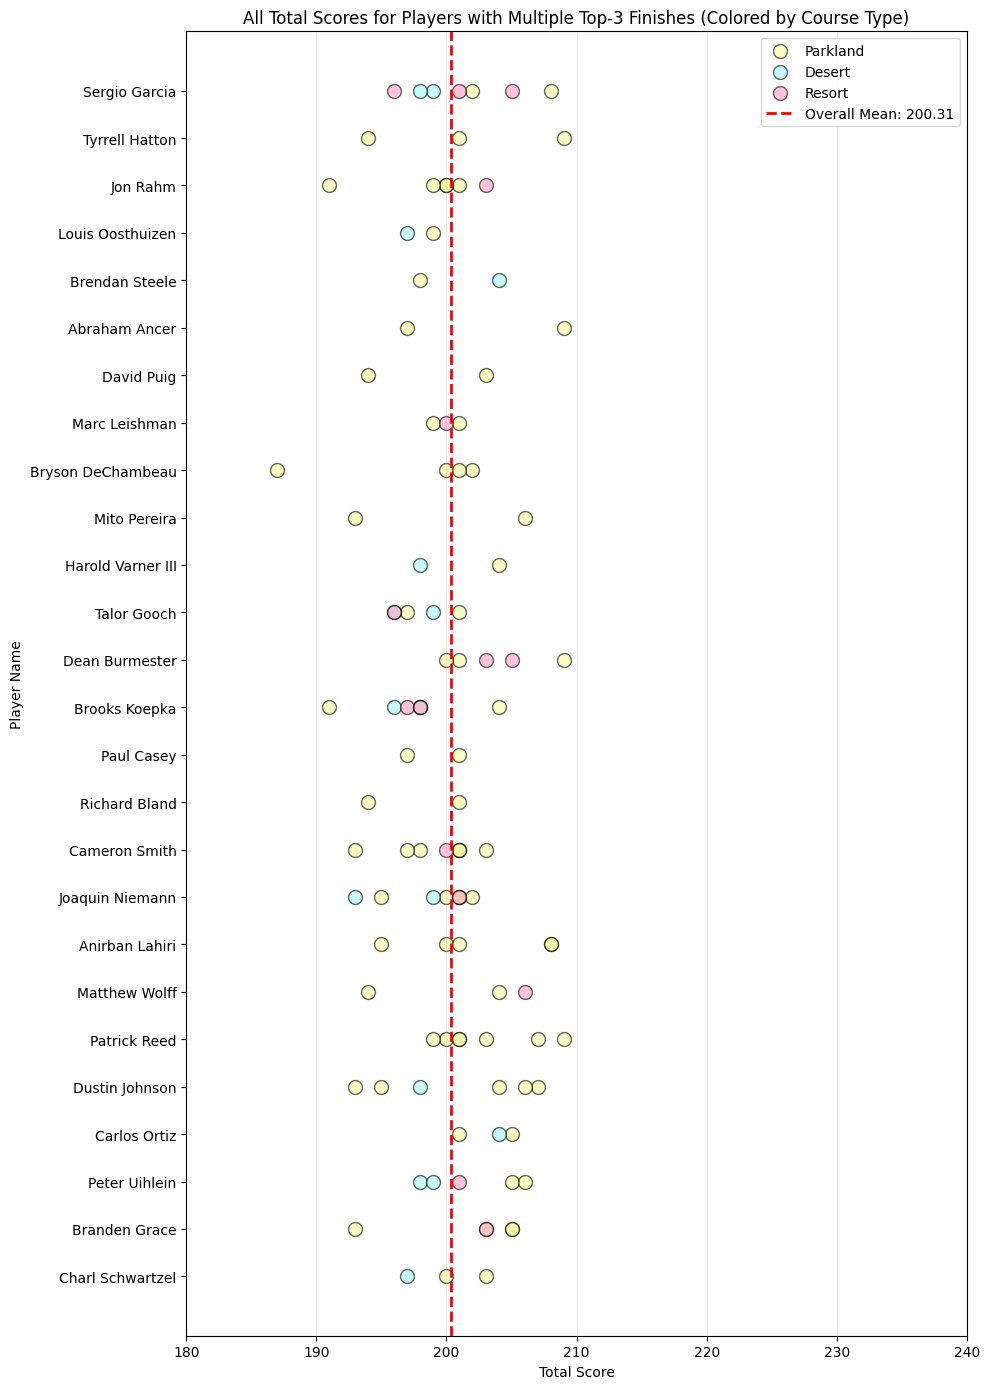

In [61]:
# Filter data for repeating players
repeating_players_data = dataset[dataset['Name'].isin(repeating_players_array)]

# Calculate overall mean score for all players in the repeating_players_array
overall3_mean_score = repeating_players_data['Total'].mean()

# Create scatter plot with all individual scores colored by course type
plt.figure(figsize=(10, 14))

# Plot each course type separately to apply colors
for course_type in repeating_players_data['course_type'].unique():
    course_data = repeating_players_data[repeating_players_data['course_type'] == course_type]
    
    plt.scatter(course_data['Total'], course_data['Name'], 
                s=100, alpha=0.6, edgecolor='black', linewidth=1, 
                color=color_map[course_type], label=course_type)

# Add vertical line for overall mean score
plt.axvline(x=overall3_mean_score, color='red', linestyle='--', linewidth=2, 
            label=f'Overall Mean: {overall3_mean_score:.2f}')

plt.xlabel('Total Score')
plt.ylabel('Player Name')
plt.title('All Total Scores for Players with Multiple Top-3 Finishes (Colored by Course Type)')
plt.xlim(180, 240)
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

I will now create a double line graph to see how total scores change over time 

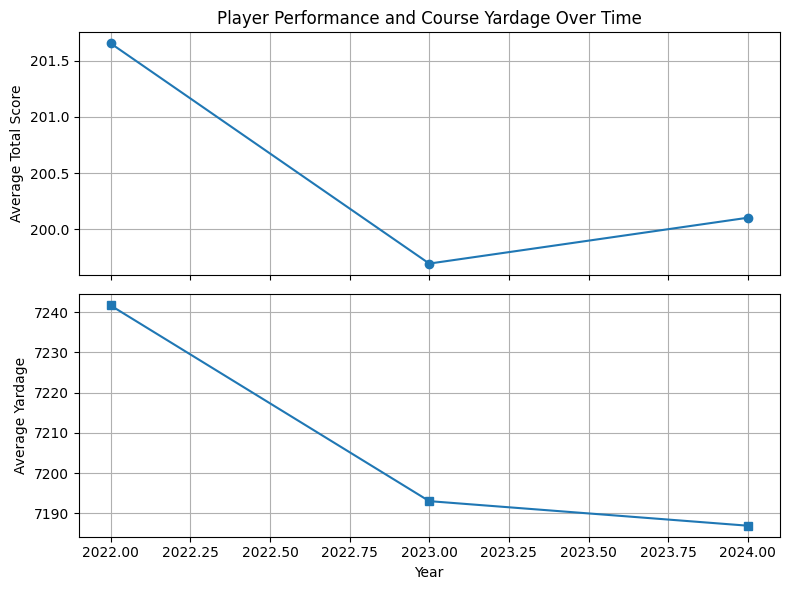

In [62]:
# First I create a dataframe with the avarage score and yardage, ChatLog 6
yearly_stats = (
    dataset.groupby('Season').agg(
        avg_score=('Total', 'mean'),
        avg_yardage=('yardage', 'mean')
    ).reset_index()
)
# plot the figure
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    sharex=True,
    figsize=(8, 6)
)

# Create the top plot- line chart of avarage score
ax1.plot(
    yearly_stats['Season'],
    yearly_stats['avg_score'],
    marker='o'
)
ax1.set_ylabel('Average Total Score')
ax1.set_title('Player Performance and Course Yardage Over Time')
ax1.grid(True)

# Create the bottom plot - line chart of avarage yardage 
ax2.plot(
    yearly_stats['Season'],
    yearly_stats['avg_yardage'],
    marker='s'
)
ax2.set_ylabel('Average Yardage')
ax2.set_xlabel('Year')
ax2.grid(True)

plt.tight_layout()
plt.show()


Now, I will create a box and whiskers plot to represent the relationship between performance of top players and time

/var/folders/hv/60j97y6n3v549mc570rdssjw0000gn/T/ipykernel_94398/156539705.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


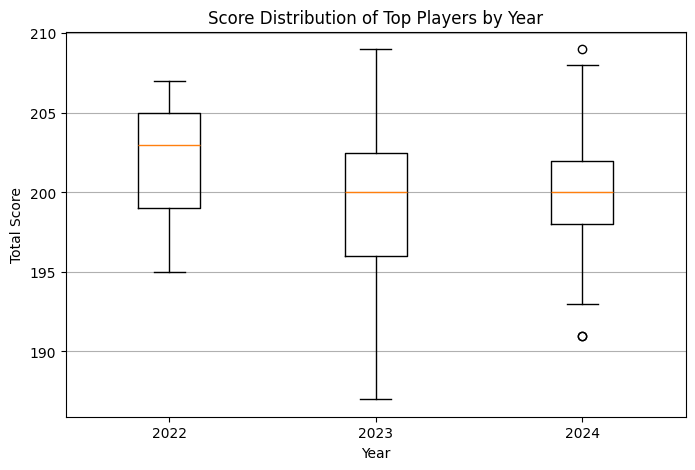

In [43]:
# Get the mean total
top_players_yearly = (
    repeating_players_data
    .groupby(['Name', 'Season'])['Total']
    .mean()
    .reset_index()
)
plt.figure(figsize=(8, 5))
# Create the boxplot, ChatLog 7 
plt.boxplot(
    [
        repeating_players_data[repeating_players_data['Season'] == year]['Total']
        for year in sorted(repeating_players_data['Season'].unique())
    ],
    labels=sorted(repeating_players_data['Season'].unique())
)

plt.xlabel('Year')
plt.ylabel('Total Score')
plt.title('Score Distribution of Top Players by Year')
plt.grid(True, axis='y')
plt.show()

ChatLogs Reference: 
ChatLog 1: Asked copilot how to apply the mapping to create new oclumns, copilot provided with the code, applied it and adjusted for the three columns 

ChatLog 2: Asked copilot how to add values on top of the bars, copilot provided with the enumerate loop, which I have applied.

ChatLog 3: Asked copilot how to build a graph with multiple bars for one gorup, copilot provided with the code in lines marked, which I have used

ChatLog 4: Asked chat for logical interpretation of my aim to plot all the total scores of players, the copilot has provided me with the structure of the loop

ChatLog 5: Asked the copilot for a function that would remove the letters from the values, copilot provided me with two lines which I have implemented.

ChatLog 6: Asked the copilot how to plot two line plots with one x axis, the copilot provided me with the code which I have implemented.

ChatLog 7: Asked the copilot how to plot a box plot, he has provided the function used in the code.